<h1 align="center"> 🧬 Healthcare Premium Prediction — Older Population with Genetic Risk</h1>

## Objective

To train and evaluate the healthcare premium prediction model for the older population (>25 years) 
using a feature structure aligned with the expected application input schema.


## Background

Previous modeling for the older population achieved high performance, indicating that the existing 
features effectively capture premium variability in this segment.

However, the younger population model was developed using an extended feature set that includes 
`genetic_risk`. To maintain a consistent feature schema across all models and ensure alignment with 
the expected application input structure, the same feature needs to be incorporated for the older population.

Since the current dataset does not include genetic risk information:

- A placeholder feature (`genetic_risk = 0`) is introduced
- This ensures schema consistency across models
- It allows seamless integration within a unified prediction pipeline
- It prepares the model for future datasets where genetic risk may be available

This approach prioritizes design consistency and scalability, even when immediate performance gains 
are not expected.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBRegressor
from joblib import dump
import math

## Dataset Loading

In [2]:
df=pd.read_excel("premiums_rest.xlsx")

### New Feature: Genetic Risk

This decision reflects a production-oriented approach, where maintaining a consistent input schema 
across models is critical for reliability, scalability, and ease of integration.

In [3]:
df['Genetical_Risk'] = 0

In [4]:
df.shape

(29904, 14)

In [5]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount', 'Genetical_Risk'],
      dtype='object')

In [6]:
df.columns=df.columns.str.replace(" ","_").str.lower()

In [7]:
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,0


<h2 align="center">🧹 Data Cleaning</h3>

- Same preprocessing steps applied as previous models
- Ensures consistency for fair comparison

### 1.Handling NA Values

In [8]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           9
employment_status        1
income_level             9
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

if we consider the overall size of the dataset, these na values arent many. So the best thing to do is discard those rows. 

In [9]:
df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

### 2. Duplicate Records

In [10]:
df.duplicated().sum()

0

In [11]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

### 3. Invalid Values

In [12]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29886.000000,29886.000000,29886.000000,29886.000000,29886.0
mean,43.396105,2.379910,23.364184,20892.303821,0.0
std,13.412657,1.431201,24.740339,6936.813440,0.0
min,26.000000,-3.000000,1.000000,3625.000000,0.0
25%,34.000000,1.000000,7.000000,15697.250000,0.0
50%,42.000000,3.000000,17.000000,20489.000000,0.0
75%,52.000000,3.000000,32.000000,26360.000000,0.0
max,356.000000,5.000000,930.000000,43471.000000,0.0


In [13]:
df[df.number_of_dependants<0].shape

(50, 14)

In [14]:
df[df.number_of_dependants<0]["number_of_dependants"].unique()

array([-1, -3], dtype=int64)

This would have occured probably because there was a bug in the data collection script. Instead of 1 and 3, it would have been saved -1 and -3.

In [15]:
df["number_of_dependants"]=abs(df["number_of_dependants"])
df["number_of_dependants"].describe()

count    29886.000000
mean         2.385933
std          1.421137
min          0.000000
25%          1.000000
50%          3.000000
75%          3.000000
max          5.000000
Name: number_of_dependants, dtype: float64

In [16]:
numeric_columns=df.select_dtypes(["float64","int64"]).columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount',
       'genetical_risk'],
      dtype='object')

### 📊 Outlier Treatment

##### age

In [17]:
df[df.age>100]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
77,224,Male,Northeast,Married,3,Normal,Regular,Salaried,25L - 40L,26,No Disease,Gold,27523,0
488,124,Female,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,> 40L,46,No Disease,Silver,11752,0
803,124,Female,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,3,No Disease,Bronze,5311,0
902,124,Female,Southwest,Unmarried,1,Overweight,No Smoking,Salaried,<10L,2,Diabetes,Bronze,10238,0
912,136,Male,Southeast,Married,3,Overweight,Regular,Self-Employed,10L - 25L,15,High blood pressure,Gold,31913,0
1097,203,Female,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,<10L,6,Diabetes,Bronze,8762,0
2211,136,Male,Southwest,Married,2,Normal,Regular,Salaried,10L - 25L,20,Diabetes & Thyroid,Gold,31402,0
2556,203,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,18,No Disease,Bronze,5254,0
3426,124,Female,Southeast,Unmarried,1,Normal,No Smoking,Self-Employed,25L - 40L,29,No Disease,Silver,10265,0
3576,136,Male,Southwest,Married,3,Underweight,Regular,Self-Employed,<10L,2,Heart disease,Silver,26127,0


In [18]:
df1=df[df.age<=100].copy()
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29828.000000,29828.000000,29828.000000,29828.000000,29828.0
mean,43.095380,2.387790,23.371530,20901.900563,0.0
std,11.041991,1.420641,24.751262,6928.457636,0.0
min,26.000000,0.000000,1.000000,6538.000000,0.0
25%,34.000000,1.000000,7.000000,15706.000000,0.0
50%,42.000000,3.000000,17.000000,20496.000000,0.0
75%,52.000000,3.000000,32.000000,26361.000000,0.0
max,72.000000,5.000000,930.000000,43471.000000,0.0


##### Income

In [19]:
quantile_threshold=df1.income_lakhs.quantile(0.999)
quantile_threshold

100.0

In [20]:
df1[df1.income_lakhs>quantile_threshold].shape

(6, 14)

In [21]:
df2=df1[df1.income_lakhs<=quantile_threshold].copy()

In [22]:
df2.shape

(29822, 14)

### Numeric Columns Analysis

#### Univariate Analysis

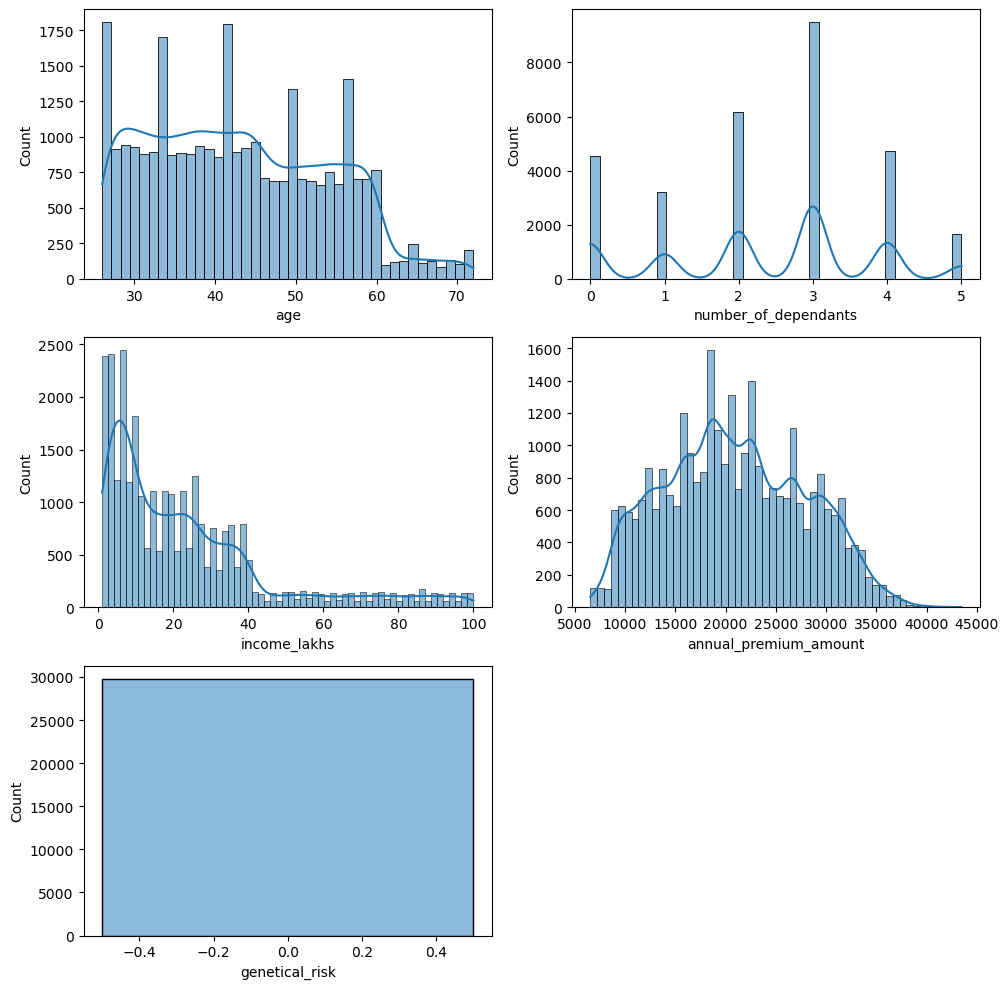

In [27]:
plt.figure(figsize=(10,10))
n_cols=2
n_rows=math.ceil(len(numeric_columns)/n_cols)
for i,col in enumerate(numeric_columns):
    plt.subplot(n_rows,n_cols,i+1)
    sns.histplot(x=df2[col],kde=True)
plt.tight_layout()
plt.show()

#### Bivariate Analysis:Numeric Columns

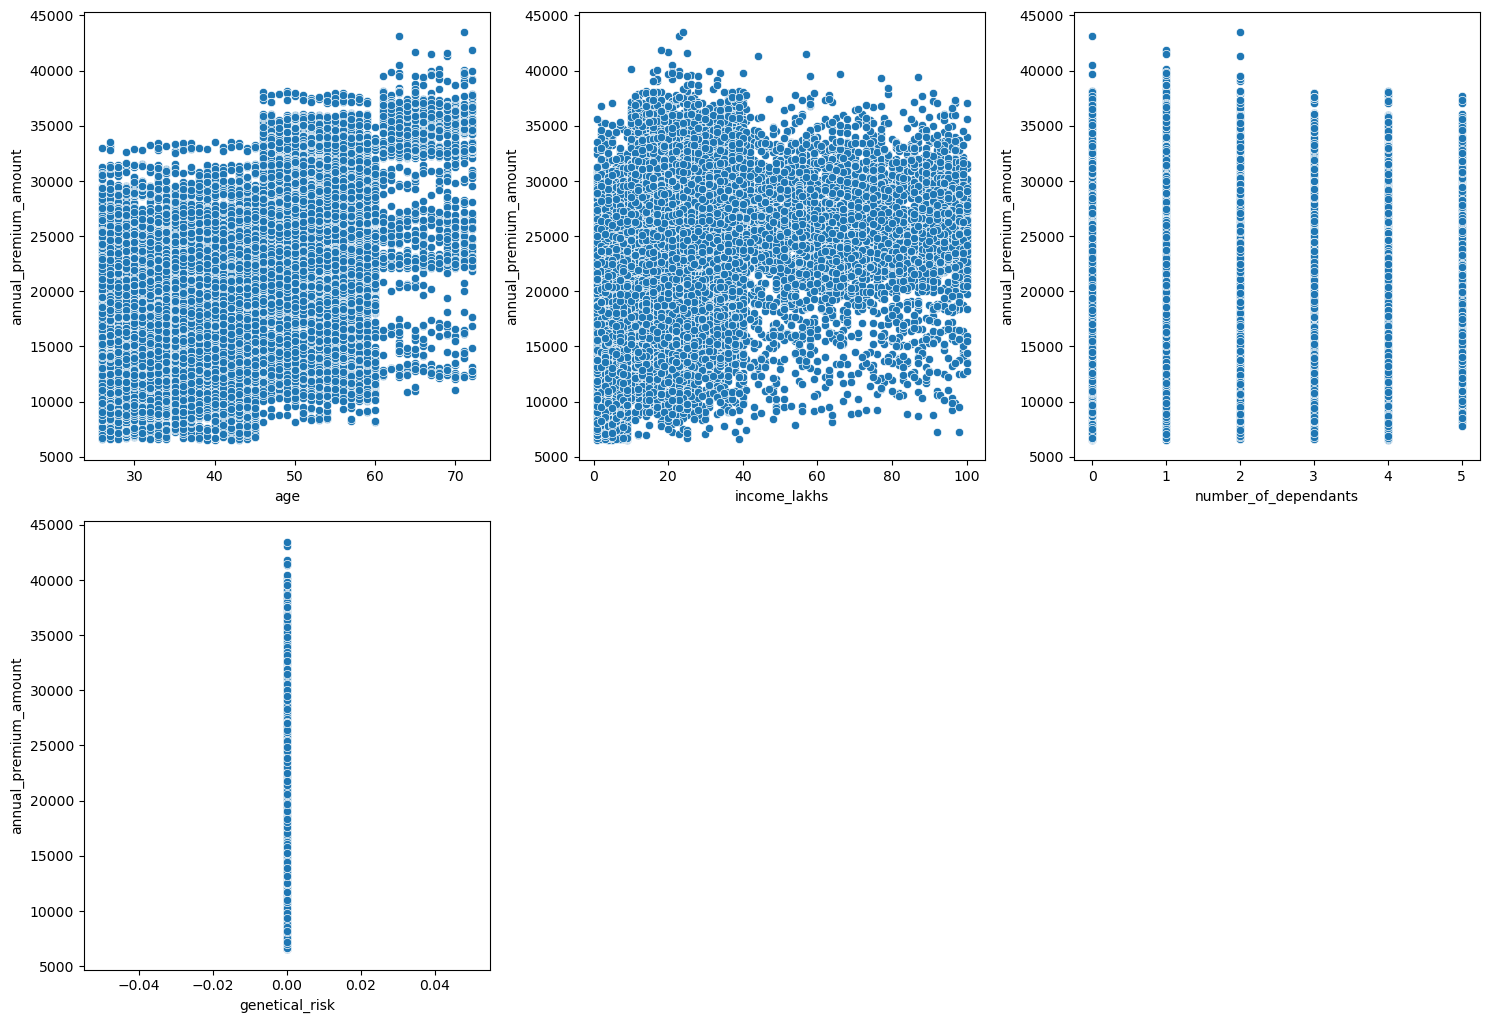

In [30]:
plt.figure(figsize=(15,15))
features = ["age", "income_lakhs", "number_of_dependants","genetical_risk"]
for i,col in enumerate(features):
    plt.subplot(3,3,i+1)
    sns.scatterplot(df2,x=col,y="annual_premium_amount")
plt.tight_layout()
plt.show()

### Categorical Columns Analysis

In [31]:
categorical_col=df.select_dtypes(include=["object","category"]).columns
categorical_col

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [32]:
for col in categorical_col:
    print(col,":", df2[col].unique())

gender : ['Male' 'Female']
region : ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status : ['No Smoking' 'Regular' 'Occasional' 'Does Not Smoke' 'Not Smoking'
 'Smoking=0']
employment_status : ['Salaried' 'Self-Employed' 'Freelancer']
income_level : ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history : ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan : ['Bronze' 'Silver' 'Gold']


smoking_status : ['No Smoking' 'Smoking=0' 'Does Not Smoke' 'Not Smoking'] - here we can see an invalid category "Smoking=0". 

No Smoking, Smoking=0, Does Not Smoke, Not Smoking is all the same which is does not smoke.

In [33]:
df2["smoking_status"]=df2["smoking_status"].replace({
    'Smoking=0':"No Smoking",
    'Does Not Smoke':"No Smoking",
    'Not Smoking':'No Smoking'
})
df2.smoking_status.unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

<h2 align="center">⚙️ Feature Engineering</h2>

In [34]:
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0


In [35]:
df2.shape

(29822, 14)

### Calculate Risk Score

In [36]:
risk_scores={
    "diabetes":6,
    "heart disease":8,
    "high blood pressure":6,
    "thyroid":5,
    "no disease":0,
    "none":0
}

df2[["disease 1","disease 2"]]=df2["medical_history"].str.split(" & ",expand=True).apply(lambda x: x.str.lower())
df2.head(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease 1,disease 2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0,diabetes,None
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0,diabetes,None
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,0,high blood pressure,None
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0,no disease,None
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,0,diabetes,None


In [37]:
df2["disease 1"]=df2["disease 1"].fillna("none")
df2["disease 2"]=df2["disease 2"].fillna("none")

#Create a new column for total risk
df2["total_risk_score"]=0

#Convert diseases to risk scores
for disease in ["disease 1","disease 2"]:
    df2["total_risk_score"]+=df2[disease].map(risk_scores)    


### Normalisng Risk Score 

In [38]:
max_score=df2["total_risk_score"].max()
min_score=df2["total_risk_score"].min()
df2["normalised_risk_score"]=(df2["total_risk_score"] - min_score) / (max_score - min_score)
df2.head(10)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease 1,disease 2,total_risk_score,normalised_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,0,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0,no disease,none,0,0.000000
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,0,diabetes,none,6,0.428571
5,33,Male,Southeast,Married,3,Normal,Regular,Self-Employed,<10L,4,Diabetes & High blood pressure,Silver,20653,0,diabetes,high blood pressure,12,0.857143
6,43,Male,Northeast,Married,3,Overweight,Regular,Salaried,> 40L,46,Thyroid,Gold,26926,0,thyroid,none,5,0.357143
7,59,Female,Southeast,Unmarried,0,Overweight,No Smoking,Freelancer,10L - 25L,21,No Disease,Gold,26101,0,no disease,none,0,0.000000
8,46,Female,Southeast,Married,4,Normal,Occasional,Self-Employed,10L - 25L,21,Thyroid,Gold,27176,0,thyroid,none,5,0.357143
9,68,Female,Southwest,Married,1,Normal,No Smoking,Self-Employed,<10L,1,Diabetes,Bronze,12596,0,diabetes,none,6,0.428571


### Ordinal encoding for ordered categories

#### Insurance Plan

In [39]:
df2["insurance_plan"]=df2["insurance_plan"].map({
    "Bronze":1,
    "Silver":2,
    "Gold":3
})

#### Income Level

In [40]:
df2.income_level.unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object)

In [41]:
df2["income_level"]=df2["income_level"].map({
    '<10L':1,
    "10L - 25L":2,
    "25L - 40L":3,
    "> 40L":4,
    
})

### One-hot encoding for nominal features

In [42]:
nominal_cols=["gender","region","marital_status","bmi_category","smoking_status","employment_status"]
df3=pd.get_dummies(df2,columns=nominal_cols,drop_first=True,dtype=int)
df3.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease 1,disease 2,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,0,diabetes,none,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,0,diabetes,none,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,0,high blood pressure,none,...,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,No Disease,3,20303,0,no disease,none,...,1,0,0,0,0,0,0,0,1,0
4,56,3,2,14,Diabetes,1,15610,0,diabetes,none,...,0,0,0,1,0,0,1,0,0,1


### Feature Selection

In [43]:
df4=df3.drop(columns=["medical_history","disease 1","disease 2","total_risk_score"])
df4

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalised_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,3,20303,0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,56,3,2,14,1,15610,0,0.428571,1,0,0,0,0,1,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29899,60,3,3,26,3,26370,0,0.428571,0,1,0,0,0,0,0,0,0,0,0,1
29900,40,0,2,16,3,29496,0,0.785714,0,0,1,0,1,0,1,0,0,1,1,0
29901,37,0,1,4,1,10957,0,0.000000,0,1,0,0,1,1,0,0,0,0,1,0
29902,47,2,4,82,3,27076,0,0.357143,0,0,1,0,0,0,0,0,0,0,1,0


### 📊 Correlation Analysis

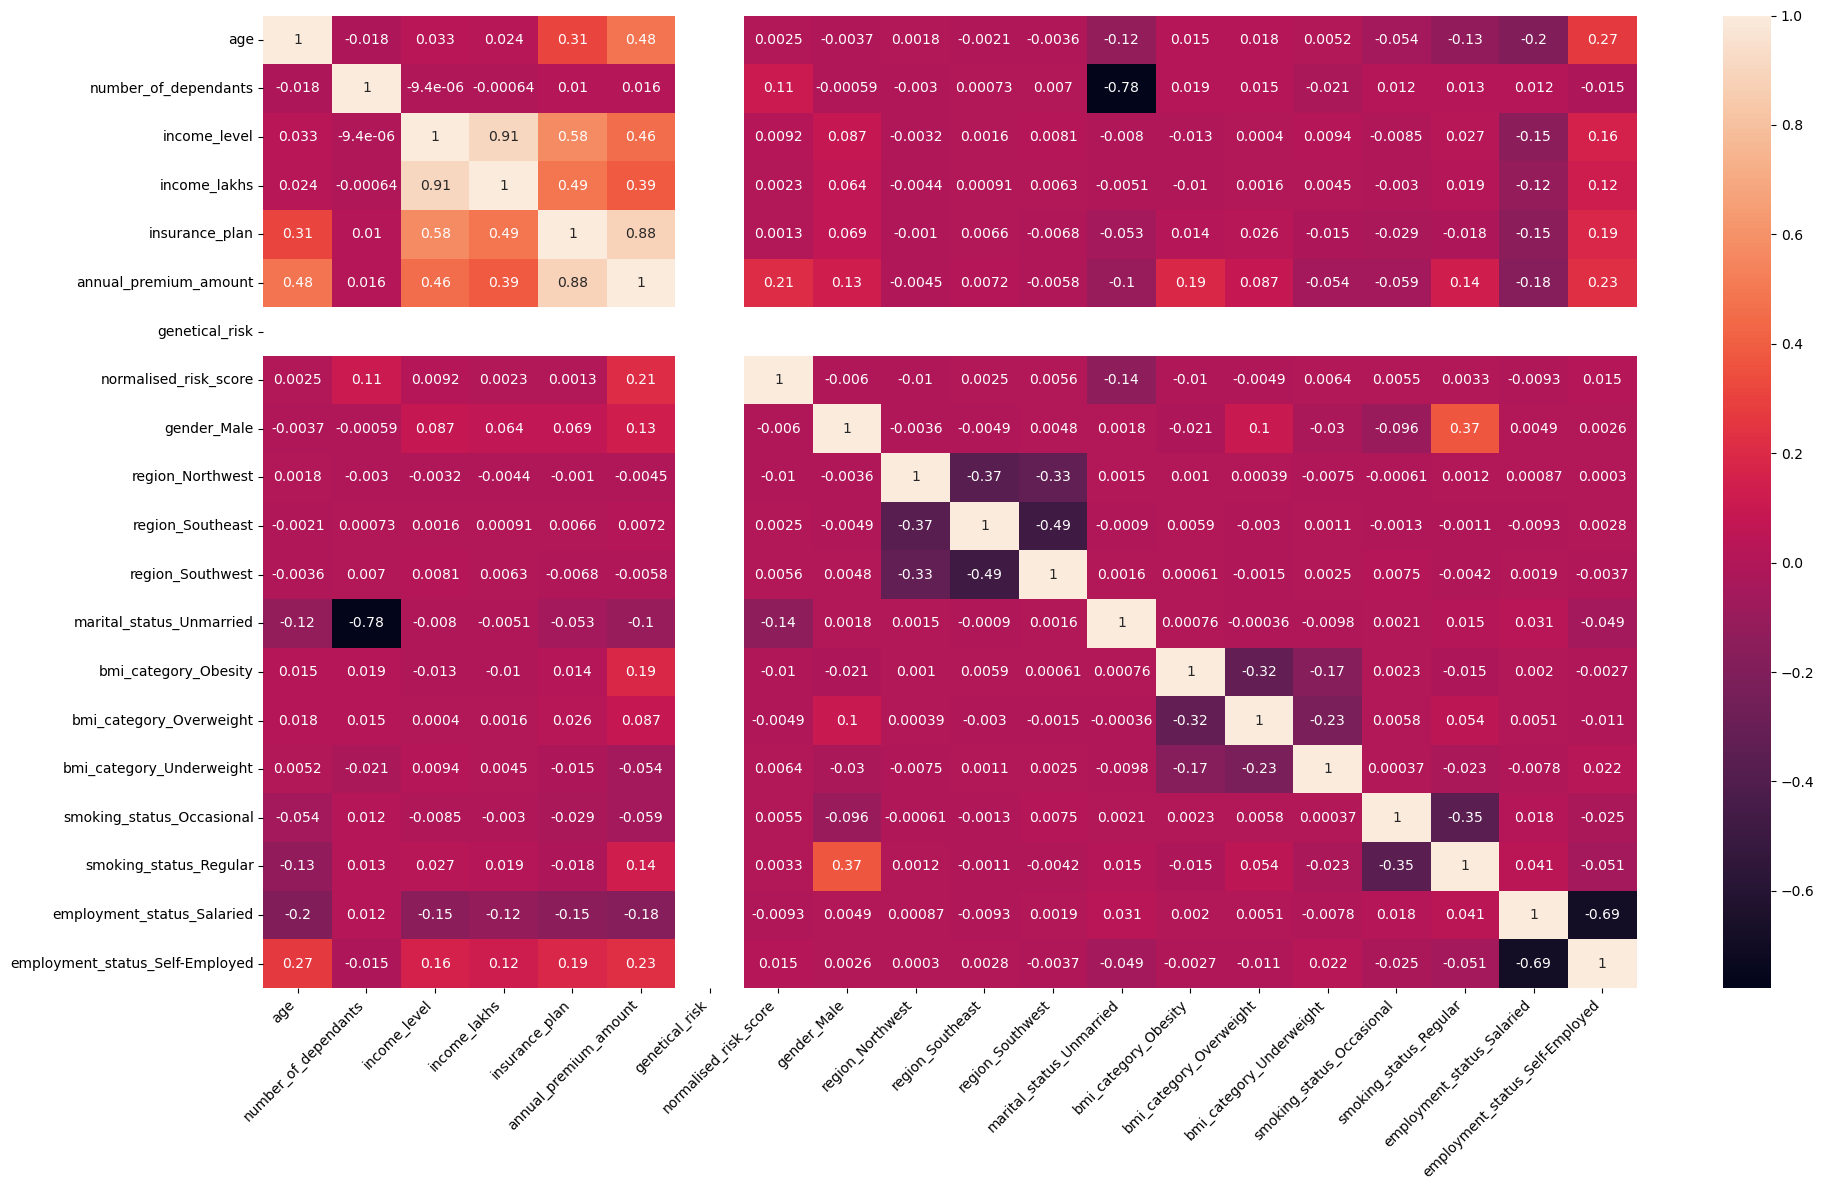

In [44]:
cm=df4.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm,annot=True)
plt.xticks(rotation=45,ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Scaling Numerical Columns

In [45]:
X=df4.drop("annual_premium_amount",axis=1)
y=df4["annual_premium_amount"]

cols_to_scale=["age","number_of_dependants","income_lakhs","income_level","insurance_plan",'genetical_risk']
scaler=MinMaxScaler()

X[cols_to_scale]=scaler.fit_transform(X[cols_to_scale])
X.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk,normalised_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.0,0.000000,0.050505,0.0,0.0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,0.065217,0.4,0.000000,0.050505,0.0,0.0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,0.500000,0.4,0.333333,0.191919,0.5,0.0,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,0.086957,0.6,1.000000,0.767677,1.0,0.0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,0.652174,0.6,0.333333,0.131313,0.0,0.0,0.428571,1,0,0,0,0,1,0,0,1,0,0,1


### Feature Selection using VIF

VIF (Variance Inflation Factor) is used to detect multicollinearity.

Even within this segment, feature relationships may differ, 
so VIF is applied again to ensure model stability.

In [46]:
def calculate_vif(data):
    vif_df=pd.DataFrame()
    vif_df["Columns"]=data.columns
    vif_df["VIF"]=[variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [47]:
calculate_vif(X)

C:\Users\elzab\anaconda3\envs\ds_env\lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Columns,VIF
0,age,3.921783
1,number_of_dependants,6.278938
2,income_level,13.890522
3,income_lakhs,11.185596
4,insurance_plan,5.271297
5,genetical_risk,NaN
6,normalised_risk_score,3.810619
7,gender_Male,2.599098
8,region_Northwest,2.123965
9,region_Southeast,2.980842


In [48]:
calculate_vif(X.drop("income_level",axis=1))

C:\Users\elzab\anaconda3\envs\ds_env\lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Columns,VIF
0,age,3.863055
1,number_of_dependants,6.278147
2,income_lakhs,2.678102
3,insurance_plan,4.574625
4,genetical_risk,NaN
5,normalised_risk_score,3.808345
6,gender_Male,2.591439
7,region_Northwest,2.123277
8,region_Southeast,2.979899
9,region_Southwest,2.708641


Now VIF is less than 10 for all columns

In [49]:
X_reduced=X.drop("income_level",axis=1)


<h2 align="center"> Model Training</h2>

Models are retrained using the updated dataset with the additional feature.

The goal is to evaluate whether performance improves compared to previous models.

In [50]:
X_train,x_test,y_train,y_test=train_test_split(X_reduced,y,test_size=0.3,random_state=10)

In [51]:
X_train.shape

(20875, 18)

In [52]:
x_test.shape

(8947, 18)

### Linear Regression

In [53]:
model_lr=LinearRegression()
model_lr.fit(X_train,y_train)
train_score=model_lr.score(X_train,y_train)
test_score=model_lr.score(x_test,y_test)
train_score,test_score

(0.9534163989489616, 0.9538448451629948)

In [54]:
np.set_printoptions(suppress=True, precision=6)
model_lr.coef_

array([ 7016.239328, -1311.764702,  -708.193369, 14835.988208,
           0.      ,  6053.624123,    37.558269,   -55.250872,
         -19.622543,   -22.289676,  -700.3202  ,  3926.812706,
        1979.456047,   612.866236,   837.395101,  2800.661843,
         -45.491367,   243.078421])

In [55]:
feature_importances=model_lr.coef_

In [56]:
coef_df=pd.DataFrame(feature_importances,index=x_test.columns,columns=["Coefficients"])
coef_df=coef_df.sort_values(by="Coefficients",ascending=True)
coef_df

,Coefficients
number_of_dependants,-1.311765e+03
income_lakhs,-7.081934e+02
marital_status_Unmarried,-7.003202e+02
region_Northwest,-5.525087e+01
employment_status_Salaried,-4.549137e+01
region_Southwest,-2.228968e+01
region_Southeast,-1.962254e+01
genetical_risk,5.911716e-12
gender_Male,3.755827e+01
employment_status_Self-Employed,2.430784e+02


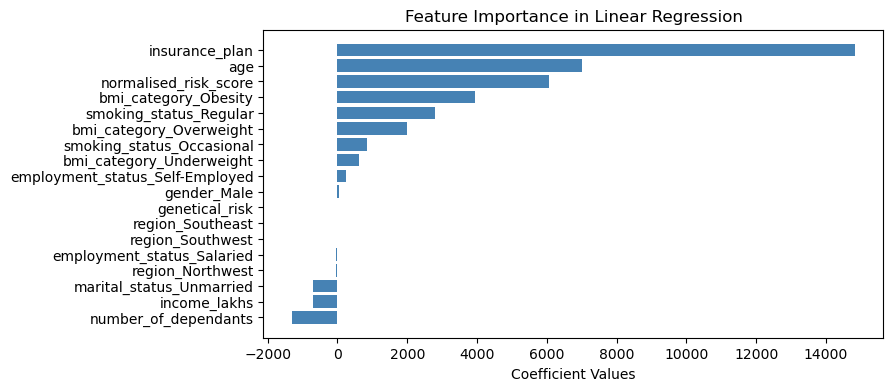

In [57]:
plt.figure(figsize=(8,4))
plt.barh(coef_df.index,coef_df["Coefficients"],color="steelblue")
plt.xlabel("Coefficient Values")
plt.title("Feature Importance in Linear Regression")
plt.show()

### XGBoost Regressor

In [58]:
model_xgb=XGBRegressor()
model_xgb.fit(X_train,y_train)
model_xgb.score(x_test,y_test)

0.9979538321495056

with xgboost we got accuracy of 99%

### Random Search CV

In [59]:
model_xgb=XGBRegressor()

param_grid={
    'n_estimators':[20,40,50],
    'learning_rate':[0.01,0.1,0.2],
    'max_depth':[3,4,5]
}

random_search=RandomizedSearchCV(model_xgb,param_grid,n_iter=10,cv=3,scoring='r2',random_state=42,n_jobs=-1)
random_search.fit(X_train,y_train)
random_search.best_score_

0.9970577955245972

In [60]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}

<h2> Model Evaluation</h2>

| Model                |R2(Without Genetic Risk)|R2(With Genetic Risk)|
|:---------------------|:----: |:---:|
|Linear               |0.95|0.95|
|XGBoost              |0.99|0.99|
|XGBoost Random Search |0.99|0.99|

### Key Observation

- While the addition of genetic risk does not improve performance, it ensures consistency in feature schema across models and supports future data integration without requiring pipeline changes.

<h1 align="center"> Error Analysis</h1>

In [61]:
best_model = random_search.best_estimator_

In [62]:
y_pred=best_model.predict(x_test)

residuals=y_pred-y_test
residuals_pct=residuals*100/y_test

results_df=pd.DataFrame({
    'actual':y_test,
    'predicted':y_pred,
    'diff':residuals,
    'diff_pct':residuals_pct
})

results_df.head()

,actual,predicted,diff,diff_pct
19713,26895,26691.470703,-203.529297,-0.756755
14750,22734,22650.751953,-83.248047,-0.366183
19932,21198,21581.894531,383.894531,1.810994
29643,9100,9425.934570,325.934570,3.581699
17076,26434,26691.470703,257.470703,0.974013


<Axes: xlabel='diff_pct', ylabel='Count'>

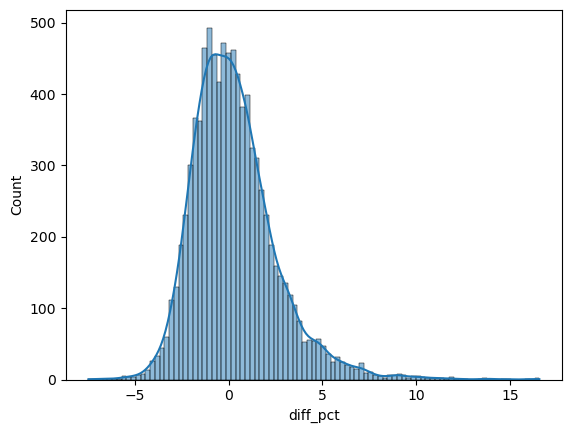

In [63]:
sns.histplot(results_df["diff_pct"],kde=True)

In [64]:
extreme_error_threshold=10
extreme_results_df=results_df[np.abs(results_df["diff_pct"])>extreme_error_threshold]
extreme_results_df.shape

(29, 4)

In [65]:
(extreme_results_df.shape[0]*100)/results_df.shape[0]

0.32413099362914943

We now have only 0.3% extreme errors.

## Export the Model

In [66]:
dump(best_model,"C:/Users/elzab/Documents/Job/Data Science Learn/project_Healthcare Premium/ML_Project_Premium_Prediction/Artefacts/model_rest.joblib")

['C:/Users/elzab/Documents/Job/Data Science Learn/project_Healthcare Premium/ML_Project_Premium_Prediction/Artefacts/model_rest.joblib']

In [67]:
scaler_with_cols={
    'scaler':scaler,
    'cols_to_scale':cols_to_scale
}
dump(scaler_with_cols,"C:/Users/elzab/Documents/Job/Data Science Learn/project_Healthcare Premium/ML_Project_Premium_Prediction/Artefacts/scaler_rest.joblib")

['C:/Users/elzab/Documents/Job/Data Science Learn/project_Healthcare Premium/ML_Project_Premium_Prediction/Artefacts/scaler_rest.joblib']